# Similarity Correlations
Calculates the Pearson and Spearman correlation between the normalized abstract similarity and normalized database similarity matrices. Only the lower-triangular values (below the diagonal) are used to avoid counting each pair twice.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
# Load normalized similarity matrices (index = paper ID)
abstract_sim = pd.read_csv('../datasets/abstract_similarity/normalized_abstract_similarity.csv', index_col=0)
database_sim = pd.read_csv('../datasets/database_similarity/normalized_database_similarity.csv', index_col=0)

print('Abstract similarity matrix shape:', abstract_sim.shape)
print('Database similarity matrix shape:', database_sim.shape)

Abstract similarity matrix shape: (142, 142)
Database similarity matrix shape: (142, 142)


In [3]:
# Align both matrices to the same set of paper IDs
common_ids = abstract_sim.index.intersection(database_sim.index)
abstract_sim = abstract_sim.loc[common_ids, common_ids.astype(str)]
database_sim = database_sim.loc[common_ids, common_ids.astype(str)]

print(f'Common IDs: {len(common_ids)}')

Common IDs: 142


In [4]:
# Extract lower-triangular indices (below the diagonal) and flatten to 1D arrays
n = len(common_ids)
lower_tri_idx = np.tril_indices(n, k=-1)

abstract_vals = abstract_sim.values[lower_tri_idx]
database_vals = database_sim.values[lower_tri_idx]

print(f'Number of unique pairs: {len(abstract_vals)}')

# Drop pairs where either value is NaN
valid_mask = ~(np.isnan(abstract_vals) | np.isnan(database_vals))
abstract_vals_clean = abstract_vals[valid_mask]
database_vals_clean = database_vals[valid_mask]

print(f'Valid pairs (after removing NaN): {len(abstract_vals_clean)}')

Number of unique pairs: 10011
Valid pairs (after removing NaN): 10011


In [5]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(abstract_vals_clean, database_vals_clean)

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(abstract_vals_clean, database_vals_clean)

print(f'Pearson  r = {pearson_r:.4f},  p = {pearson_p:.4e}')
print(f'Spearman r = {spearman_r:.4f},  p = {spearman_p:.4e}')

Pearson  r = 0.2199,  p = 6.3064e-110
Spearman r = 0.2344,  p = 5.7411e-125


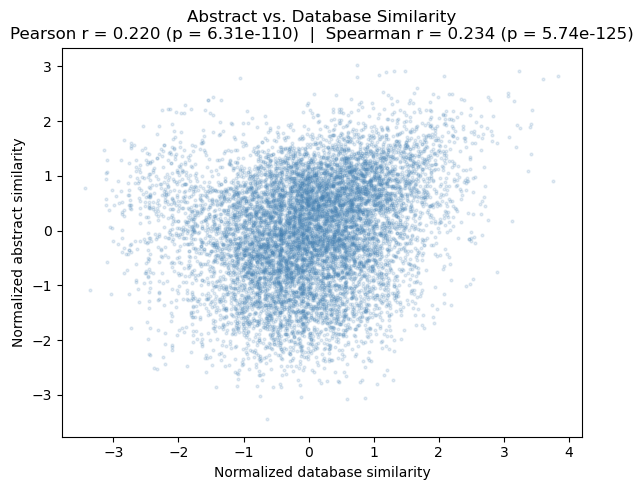

In [6]:
# Scatter plot of the two similarity vectors
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(database_vals_clean, abstract_vals_clean, alpha=0.15, s=4, color='steelblue')
ax.set_xlabel('Normalized database similarity')
ax.set_ylabel('Normalized abstract similarity')
ax.set_title(
    f'Abstract vs. Database Similarity\n'
    f'Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})  |  '
    f'Spearman r = {spearman_r:.3f} (p = {spearman_p:.2e})'
)
plt.tight_layout()
plt.show()